# Mietpreisvorhersage — Wohnungsgröße & Zimmeranzahl vs. Miete

**Ziel:** Die Beziehung zwischen zwei Merkmalen — Wohnungsgröße (m²) und Anzahl der Zimmer — und der Miete (in €) visualisieren, um eine Mietpreisvorhersage mit zwei abhängigen Werten (Eingabegrößen) zu erstellen.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)
print("Imports OK")

Imports OK


## 1. Daten erzeugen

Wir tragen 10 Wohnungen von Hand ein: Wohnungsgröße (m²), Anzahl der Zimmer und die dazugehörige Miete (€).

In [2]:
# Manuell eingetragene Daten: (Wohnungsgröße, Anzahl Zimmer) → Miete
groesse = np.array([25, 35, 45, 55, 65, 75, 90, 100, 120, 140])
zimmer  = np.array([ 1,  1,  2,  2,  2,  3,  3,   4,   4,   5])
miete   = np.array([380, 480, 560, 600, 700, 760, 900, 940, 1120, 1300])

print(f"{len(groesse)} Wohnungen erfasst")
print(f"Größe: {groesse.min()}–{groesse.max()} m²")
print(f"Zimmer: {zimmer.min()}–{zimmer.max()}")
print(f"Miete: {miete.min()}–{miete.max()} €")

10 Wohnungen erfasst
Größe: 25–140 m²
Zimmer: 1–5
Miete: 380–1300 €


## 2. Daten visualisieren

Da wir jetzt zwei abhängige Werte (Wohnungsgröße und Zimmeranzahl) haben, brauchen wir einen 3D-Scatterplot: Die beiden Merkmale spannen die Grundfläche auf, die Miete zeigt sich in der Höhe.

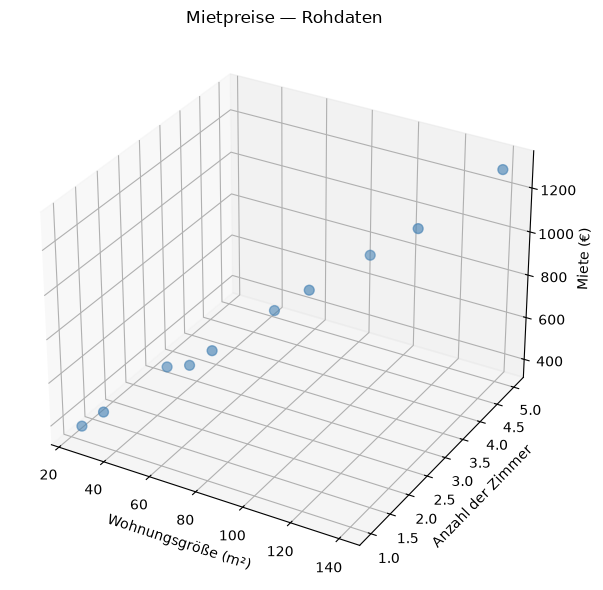

In [3]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(groesse, zimmer, miete, color="steelblue", alpha=0.8, s=50)
ax.set_xlabel("Wohnungsgröße (m²)")
ax.set_ylabel("Anzahl der Zimmer")
ax.set_zlabel("Miete (€)")
ax.set_title("Mietpreise — Rohdaten")
plt.tight_layout()
plt.show()

## 3. Eine Ebene einzeichnen

Mit einem abhängigen Wert war die beste Anpassung eine Gerade `y = w * x + b`. Mit zwei abhängigen Werten wird daraus eine Ebene:

`miete = w0 * groesse + w1 * zimmer + b`

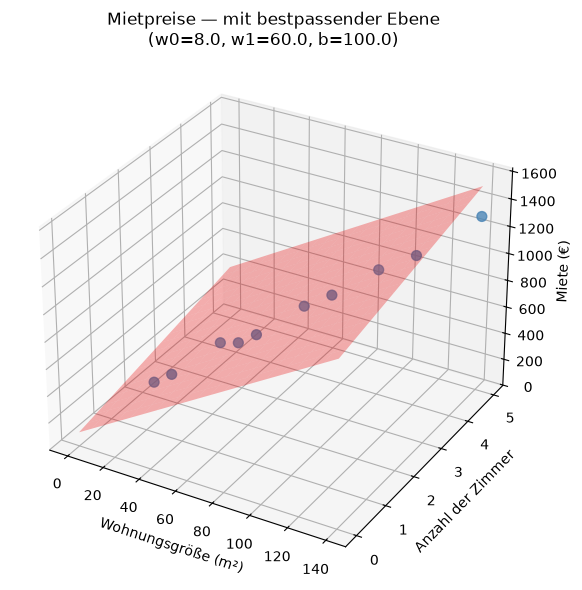

In [4]:
# hier anpassen:
w0 = 8.0
w1 = 60.0
b = 100.0


xx, yy = np.meshgrid(
    np.linspace(0, groesse.max(), 20),
    np.linspace(0, zimmer.max(), 20),
)
zz = w0 * xx + w1 * yy + b

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(groesse, zimmer, miete, color="steelblue", alpha=0.9, s=50, label="Daten")
ax.plot_surface(xx, yy, zz, color="red", alpha=0.3)
ax.set_xlabel("Wohnungsgröße (m²)")
ax.set_ylabel("Anzahl der Zimmer")
ax.set_zlabel("Miete (€)")
ax.set_title(f"Mietpreise — mit bestpassender Ebene\n(w0={w0:.1f}, w1={w1:.1f}, b={b:.1f})")
plt.tight_layout()
plt.show()

## 4. Vorhersage für eine neue Wohnung

In [5]:
neue_groesse, neue_zimmer = 80, 3
vorhersage = w0 * neue_groesse + w1 * neue_zimmer + b
print(f"Wohnung mit {neue_groesse} m² und {neue_zimmer} Zimmern:")
print(f"Vorhergesagte Miete = {vorhersage:.0f} €")

Wohnung mit 80 m² und 3 Zimmern:
Vorhergesagte Miete = 920 €


---
## Zusammenfassung

- Wir haben 10 Wohnungen von Hand mit Wohnungsgröße, Zimmeranzahl und Miete erfasst
- Mit zwei abhängigen Werten (Wohnungsgröße und Zimmeranzahl) reicht ein 2D-Scatterplot nicht mehr — die Daten wurden in 3D dargestellt
- Statt einer bestpassenden Geraden wird bei zwei Eingabegrößen eine bestpassende Ebene gesucht: `miete = w0 * groesse + w1 * zimmer + b`
- Mit dieser Ebene lässt sich die Miete für eine neue Wohnung anhand ihrer Größe und Zimmeranzahl vorhersagen